# 01. Developer Demographics Profile

This notebook explores the demographics of Stack Overflow Survey respondents from 2021 to 2025. We analyze:
1. Geographic distribution (Top countries)
2. Age demographics
3. Gender diversity
4. Overall and professional coding experience
5. Most common developer roles

In [1]:
import os
import sys
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set style for visuals
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (12, 6)
plt.rcParams["font.size"] = 12

# Resolve path to sql_connector relative to this notebook
current_dir = os.path.abspath('')
project_root = os.path.dirname(current_dir)
silver_utils_dir = os.path.join(project_root, 'Data Warehouse', 'Silver Layer', 'utils')
sys.path.append(silver_utils_dir)

# Ensure the images output directory exists
images_dir = os.path.join(current_dir, 'images')
os.makedirs(images_dir, exist_ok=True)

from sql_connector import SQLConnector

db = SQLConnector("Stack_Overflow_Survey")
db.connect()

Successfully Connected to Stack_Overflow_Survey


### 1. Geographic Distribution (Top 10 Countries)

Let's see where the survey respondents are located.

c:\Users\Ayush\Git Repo\Stack-Over-Flow-Survey-Data-Engineering-Project\Data Warehouse\Silver Layer\utils\sql_connector.py:46: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql_query(query, self.conn)


Query executed successfully


C:\Users\Ayush\AppData\Local\Temp\ipykernel_11288\3069345137.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_10, x='Count', y='Country', palette='viridis')


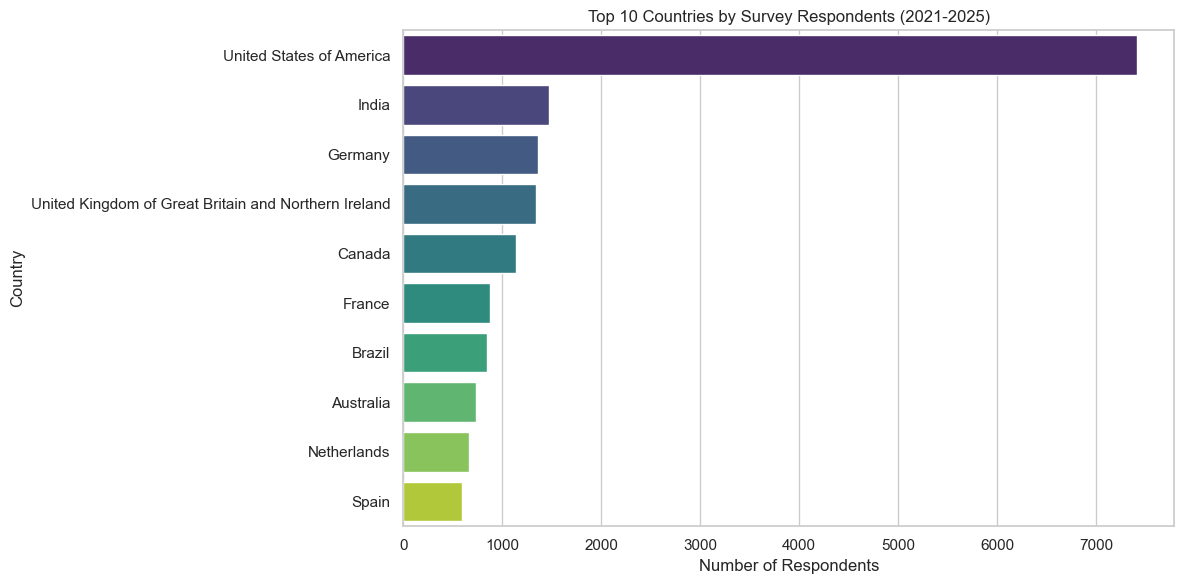

In [2]:
country_query = """
SELECT Country, COUNT(*) as Count
FROM Snowflake.Dim_Demographics
WHERE Country IS NOT NULL AND Country <> 'Unknown' AND Country <> ''
GROUP BY Country
ORDER BY Count DESC;
"""
df_country = db.read_query(country_query)

if df_country is not None and not df_country.empty:
    plt.figure(figsize=(12, 6))
    top_10 = df_country.head(10)
    sns.barplot(data=top_10, x='Count', y='Country', palette='viridis')
    plt.title('Top 10 Countries by Survey Respondents (2021-2025)')
    plt.xlabel('Number of Respondents')
    plt.ylabel('Country')
    plt.tight_layout()
    plt.savefig(os.path.join(images_dir, '01_top_countries.png'), dpi=300)
    plt.show()
else:
    print("No data retrieved or failed query.")

### 2. Age Demographics

Let's analyze the age distribution of developers over time.

c:\Users\Ayush\Git Repo\Stack-Over-Flow-Survey-Data-Engineering-Project\Data Warehouse\Silver Layer\utils\sql_connector.py:46: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql_query(query, self.conn)


Query executed successfully


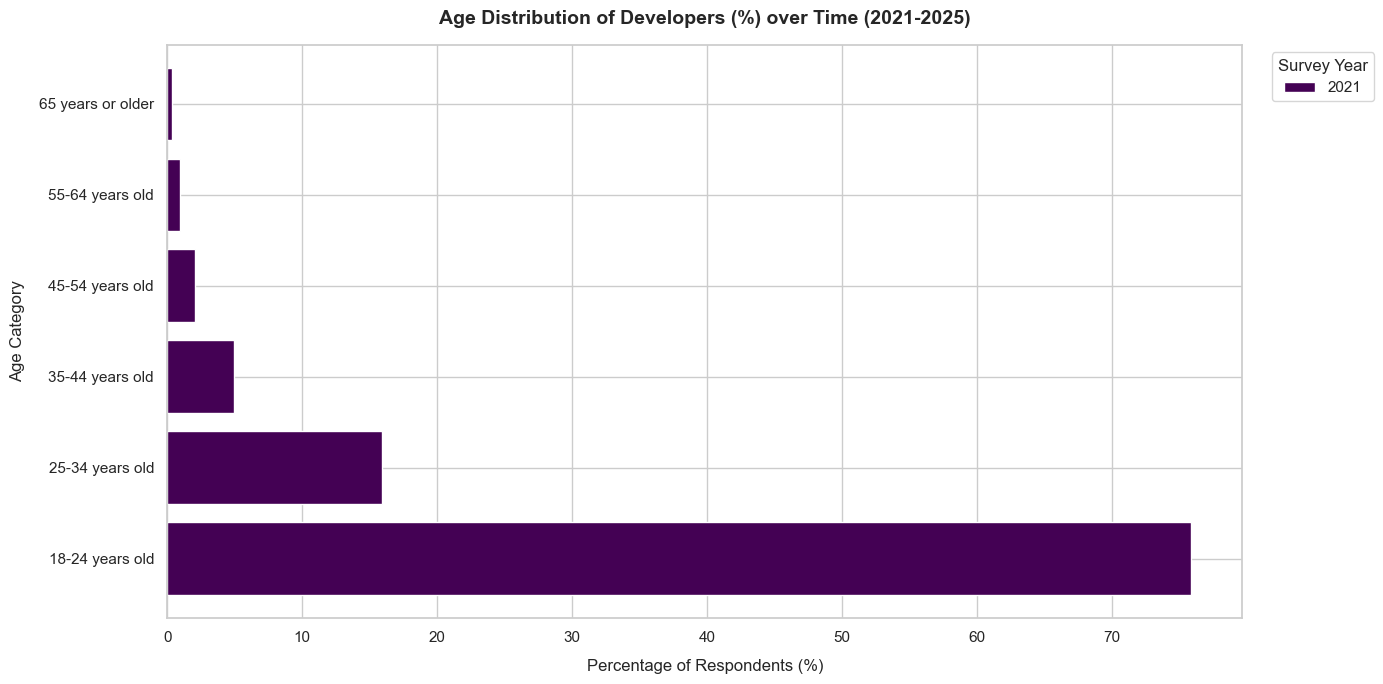

In [4]:
age_query = """
SELECT YEAR(f.SurveyYear) AS Year, d.AgeCode, COUNT(DISTINCT f.ResponseKey) AS Count
FROM Snowflake.Fact_Survey_Core f
JOIN Snowflake.Dim_Demographics d ON f.Dim_DemographicsID = d.Dim_DemographicsID
WHERE d.AgeCode IS NOT NULL 
GROUP BY YEAR(f.SurveyYear), d.AgeCode;
"""
df_age = db.read_query(age_query)

if df_age is not None and not df_age.empty :
    df_age['AgeCode'] = df_age['AgeCode'].astype(str).str.strip()
    df_age['Year'] = df_age['Year'].astype(int)
    
    age_map = {
        # 18-24 Buckets
        '18-24': '18-24 years old',
        '18-24 years old': '18-24 years old',
        
        # 25-34 Buckets
        '25-34': '25-34 years old',
        '25-34 years old': '25-34 years old',
        
        # 35-44 Buckets
        '35-44': '35-44 years old',
        '35-44 years old': '35-44 years old',
        
        # 45-54 Buckets
        '45-54': '45-54 years old',
        '45-54 years old': '45-54 years old',
        
        # 55-64 Buckets
        '55-64': '55-64 years old',
        '55-64 years old': '55-64 years old',
        
        # 65+ Buckets
        '>64': '65 years or older',
        '65 years or older': '65 years or older'
    }
    
    df_age['Age_Group'] = df_age['AgeCode'].map(age_map)
    df_age = df_age.dropna(subset=['Age_Group'])
    
    df_clean = df_age.groupby(['Year', 'Age_Group'])['Count'].sum().reset_index()
    
    df_pivot = df_clean.pivot(index='Age_Group', columns='Year', values='Count').fillna(0)
    df_pct = df_pivot.div(df_pivot.sum(axis=0), axis=1) * 100
    
    y_order = [
      '18-24 years old', '25-34 years old', 
        '35-44 years old', '45-54 years old', '55-64 years old', '65 years or older'
    ]
    df_pct = df_pct.reindex(y_order)
    
    sns.set_theme(style="whitegrid")
    df_pct.plot(kind='barh', figsize=(14, 7), colormap='viridis', width=0.8)
    
    plt.title('Age Distribution of Developers (%) over Time (2021-2025)', fontsize=14, fontweight='bold', pad=15)
    plt.xlabel('Percentage of Respondents (%)', fontsize=12, labelpad=10)
    plt.ylabel('Age Category', fontsize=12, labelpad=10)
    plt.legend(title='Survey Year', bbox_to_anchor=(1.02, 1), loc='upper left')
    
    plt.tight_layout()
    plt.savefig(os.path.join(images_dir, '01_age_distribution_clean.png'), dpi=300)
    plt.show()

else:
    print("No age data available.")

### 3. Gender Diversity

Let's see gender representation and how it evolves.

c:\Users\Ayush\Git Repo\Stack-Over-Flow-Survey-Data-Engineering-Project\Data Warehouse\Silver Layer\utils\sql_connector.py:46: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql_query(query, self.conn)


Query executed successfully


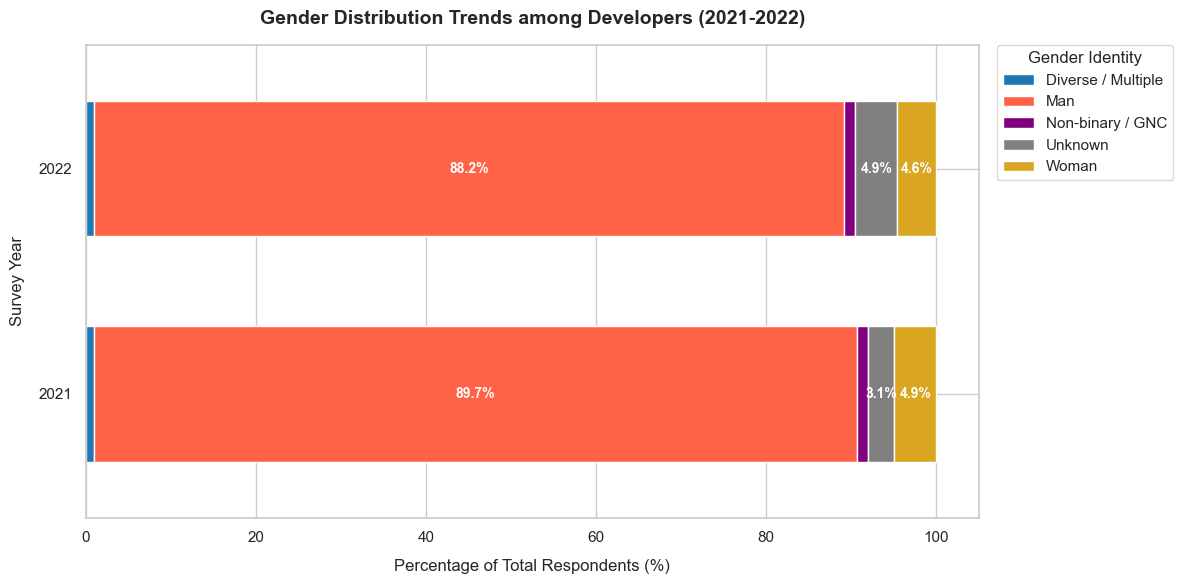

In [7]:
gender_query = """
SELECT YEAR(f.SurveyYear) AS Year, d.Gender_Clean, COUNT(DISTINCT f.ResponseKey) AS Count
FROM Snowflake.Fact_Survey_Core f
JOIN Snowflake.Dim_Demographics d ON f.Dim_DemographicsID = d.Dim_DemographicsID
WHERE d.Gender_Clean IS NOT NULL 
GROUP BY YEAR(f.SurveyYear), d.Gender_Clean;
"""
df_gender = db.read_query(gender_query)

if df_gender is not None and not df_gender.empty:
    df_gender['Gender_Clean'] = df_gender['Gender_Clean'].astype(str).str.strip()
    df_gender['Year'] = df_gender['Year'].astype(int)
    
    df_gender_pivot = df_gender.pivot(index='Year', columns='Gender_Clean', values='Count').fillna(0)
    df_gender_pct = df_gender_pivot.div(df_gender_pivot.sum(axis=1), axis=0) * 100
    
    sns.set_theme(style="whitegrid")
    ax = df_gender_pct.plot(
        kind='barh', 
        stacked=True, 
        figsize=(12, 6), 
        color=['#1f77b4', 'tomato', 'purple', 'gray', 'goldenrod'],
        width=0.6
    )
    
    plt.title('Gender Distribution Trends among Developers (2021-2022)', fontsize=14, fontweight='bold', pad=15)
    plt.xlabel('Percentage of Total Respondents (%)', fontsize=12, labelpad=10)
    plt.ylabel('Survey Year', fontsize=12, labelpad=10)
    plt.legend(title='Gender Identity', bbox_to_anchor=(1.02, 1), loc='upper left', borderaxespad=0)
    
    for p in ax.patches:
        width = p.get_width()
        if width > 1.5:  
            x = p.get_x() + width / 2
            y = p.get_y() + p.get_height() / 2
            ax.annotate(f'{width:.1f}%', (x, y), ha='center', va='center', color='white', fontweight='bold', fontsize=10)

    plt.tight_layout()
    plt.savefig(os.path.join(images_dir, '01_gender_distribution.png'), dpi=300)
    plt.show()
else:
    print("No gender data available.")

### 4. Experience Profiles

Let's check the relationship between years of coding overall vs. professional coding experience.

c:\Users\Ayush\Git Repo\Stack-Over-Flow-Survey-Data-Engineering-Project\Data Warehouse\Silver Layer\utils\sql_connector.py:46: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql_query(query, self.conn)


Query executed successfully


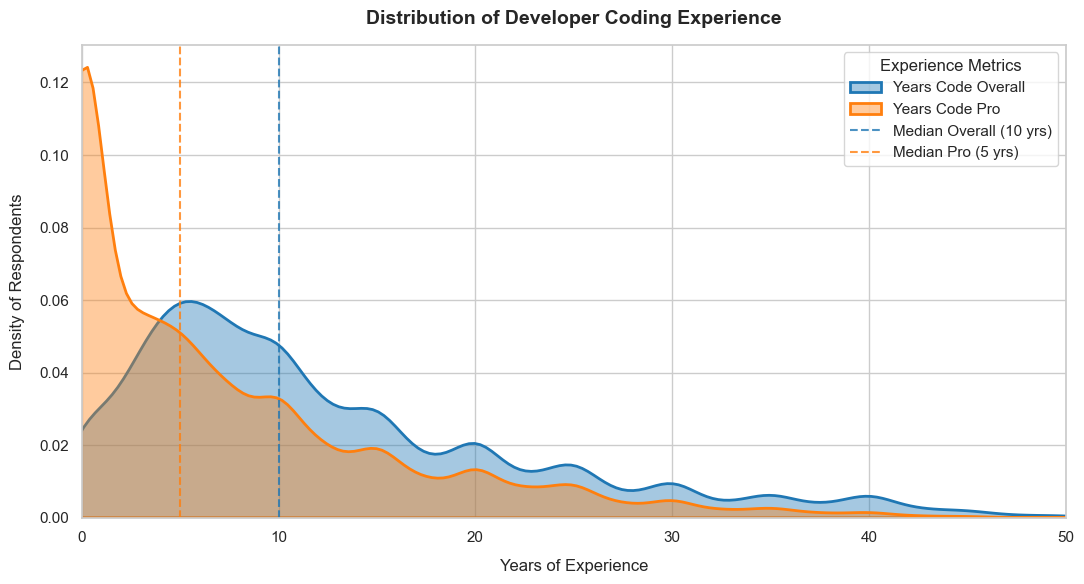

In [8]:
exp_query = """
SELECT YearsCode, YearsCodePro 
FROM Snowflake.Fact_Survey_Core 
WHERE YearsCode IS NOT NULL AND YearsCodePro IS NOT NULL 
  AND YearsCode <= 50 AND YearsCodePro <= 50;
"""
df_exp = db.read_query(exp_query)

if df_exp is not None and not df_exp.empty:
    # 1. Standardize styling and layout
    sns.set_theme(style="whitegrid")
    plt.figure(figsize=(11, 6))
    
    # 2. Plot smooth, filled area distributions (bw_adjust=1.5 removes the artificial waves)
    sns.kdeplot(data=df_exp, x='YearsCode', fill=True, color='#1f77b4', label='Years Code Overall', alpha=0.4, bw_adjust=1.5, linewidth=2)
    sns.kdeplot(data=df_exp, x='YearsCodePro', fill=True, color='#ff7f0e', label='Years Code Pro', alpha=0.4, bw_adjust=1.5, linewidth=2)
    
    # 3. Calculate and add vertical lines for the medians (makes it highly readable)
    median_overall = df_exp['YearsCode'].median()
    median_pro = df_exp['YearsCodePro'].median()
    
    plt.axvline(median_overall, color='#1f77b4', linestyle='--', linewidth=1.5, alpha=0.8, label=f'Median Overall ({int(median_overall)} yrs)')
    plt.axvline(median_pro, color='#ff7f0e', linestyle='--', linewidth=1.5, alpha=0.8, label=f'Median Pro ({int(median_pro)} yrs)')
    
    # 4. Clear titles and axes formatting
    plt.title('Distribution of Developer Coding Experience', fontsize=14, fontweight='bold', pad=15)
    plt.xlabel('Years of Experience', fontsize=12, labelpad=10)
    plt.ylabel('Density of Respondents', fontsize=12, labelpad=10)
    
    # Set hard boundaries so the density curve doesn't bleed below 0 or past 50
    plt.xlim(0, 50) 
    
    # Place the legend cleanly
    plt.legend(title='Experience Metrics', loc='upper right', frameon=True)
    
    plt.tight_layout()
    plt.savefig(os.path.join(images_dir, '01_experience_distribution_clean.png'), dpi=300)
    plt.show()
else:
    print("No experience data available.")

### 5. Developer Roles / Jobs

Let's see what roles are the most common in 2025.

c:\Users\Ayush\Git Repo\Stack-Over-Flow-Survey-Data-Engineering-Project\Data Warehouse\Silver Layer\utils\sql_connector.py:46: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql_query(query, self.conn)


Query executed successfully


C:\Users\Ayush\AppData\Local\Temp\ipykernel_11288\2977708009.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_roles_2025, x='Count', y='DevType', palette='magma')


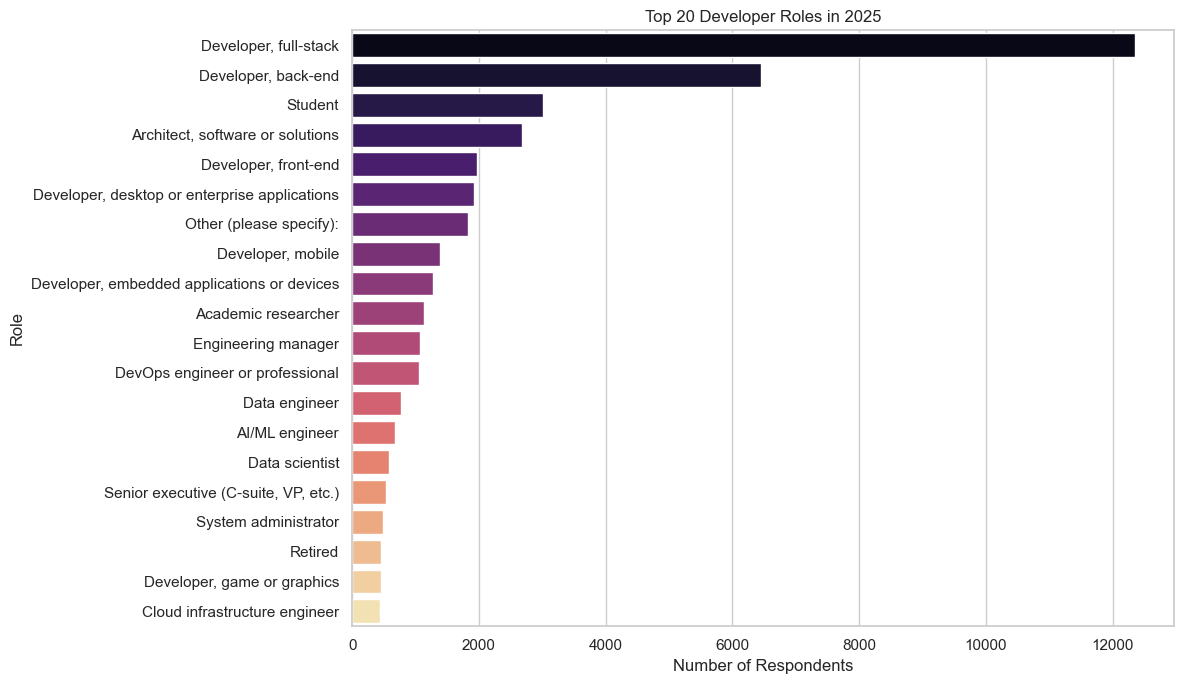

In [6]:
roles_query = """
SELECT YEAR(f.SurveyYear) AS Year, b.DevType_Clean AS DevType, COUNT(DISTINCT f.ResponseKey) AS Count
FROM Snowflake.Fact_Survey_Core f
JOIN Snowflake.Bridge_DevType_Clean b ON f.ResponseKey = b.ResponseKey
WHERE b.DevType_Clean IS NOT NULL AND b.DevType_Clean <> 'Unknown'
GROUP BY YEAR(f.SurveyYear), b.DevType_Clean;
"""
df_roles = db.read_query(roles_query)

if df_roles is not None and not df_roles.empty:
    df_roles_2025 = df_roles[df_roles['Year'] == 2025].sort_values(by='Count', ascending=False).head(20)
    plt.figure(figsize=(12, 7))
    sns.barplot(data=df_roles_2025, x='Count', y='DevType', palette='magma')
    plt.title('Top 20 Developer Roles in 2025')
    plt.xlabel('Number of Respondents')
    plt.ylabel('Role')
    plt.tight_layout()
    plt.savefig(os.path.join(images_dir, '01_dev_roles_2025.png'), dpi=300)
    plt.show()
else:
    print("No roles data available.")

In [7]:
db.close()

Connection closed.
